# **🩺 Breast Cancer Prediction**

This notebook performs a complete **exploration + visualization + model training + prediction** workflow using the **Breast Cancer Wisconsin Diagnostic Dataset**.  
The goal is to analyze the dataset, understand the distribution of cancer-related features, train a high-performance model using **CatBoost**, and finally build a **custom prediction function** for real-world testing.

---

## 🔎 **What This Code Does**

### **1️⃣ Loads and Prepares the Dataset**
- Imports the Breast Cancer dataset from scikit-learn  
- Converts it into a clean pandas DataFrame  
- Appends the `target` column (0 = benign, 1 = malignant)  
- Displays:
  - First 5 rows  
  - Statistical summary (`describe()`)  
  - Count of benign vs malignant samples  

---

### **2️⃣ Exploratory Data Analysis (EDA)**
- Selects the first few important features for visualization  
- Generates a **pairplot** using seaborn to show:
  - Feature relationships  
  - Class distribution  
  - KDE curves on diagonal  
- Helps in visually understanding how features differ between benign and malignant cases  

---

### **3️⃣ Feature & Target Preparation**
- Separates the dataset into:
  - **X** = features  
  - **y** = target labels  
- Performs an 80/20 train–test split  
- Ensures reproducibility using `random_state=42`  

---

### **4️⃣ Model Training using CatBoost**
A powerful gradient boosting model is trained with:

- **Iterations:** 300–1000  
- **Learning rate:** 0.1  
- **Depth:** 6  
- **Loss function:** Logloss  
- **Eval metric:** Accuracy  

During training:
- Uses test data as validation set  
- Applies **early stopping** to avoid overfitting  

---

### **5️⃣ Model Evaluation**
After prediction on test data, the following metrics are computed:

- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**

These metrics provide a complete understanding of how well the classifier is performing on malignant vs benign detection.

---

### **6️⃣ Custom Prediction Function**
A dedicated function is provided to predict cancer type using **user-defined feature values**.

The function:
- Builds a DataFrame from input values  
- Uses the trained CatBoost model to predict  
- Returns a **human-readable result**:
  - *“Benign (not having breast cancer)”*  
  - *“Malignant (having breast cancer)”*

---

## 🎯 **Final Outcome**

By the end of this code execution, you will have:

- A fully explored and visualized medical dataset  
- A trained, optimized **CatBoost classification model**  
- Complete evaluation metrics  
- A ready-to-use function for real-time breast cancer predictions  
- A practical template for building advanced medical-AI classification systems  


===== HEAD (first 5 rows) =====
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perime

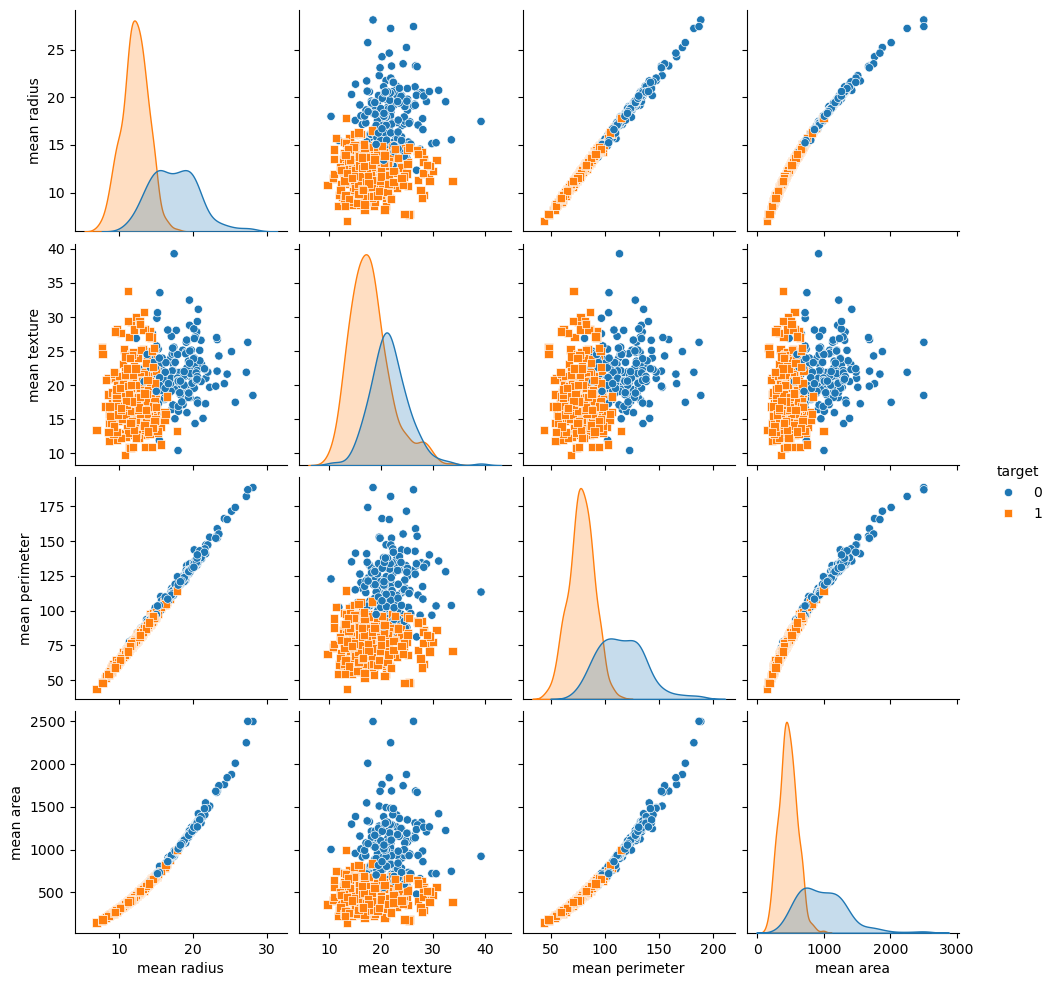


===== MODEL EVALUATION METRICS =====
Accuracy : 0.9736842105263158
Precision: 0.9726027397260274
Recall   : 0.9861111111111112
F1 Score : 0.9793103448275862

===== PREDICTION RESULT =====
The person is predicted to be malignant (having breast cancer).


In [2]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
import numpy as np
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the breast cancer dataset
data = load_breast_cancer()

# Create a DataFrame from the dataset
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Display the first few rows of the dataset
print("\n===== HEAD (first 5 rows) =====")
print(df.head())

# Summary statistics
print("\n===== SUMMARY STATISTICS =====")
print(df.describe())

# Count of target values
print("\n===== TARGET VALUE COUNTS =====")
print(df['target'].value_counts())

# Pairplot for selected features (first 4 + target)
selected_features = list(df.columns[:4]) + ['target']
sns.pairplot(df[selected_features], hue='target', markers=["o", "s"], diag_kind='kde')
plt.show()

# Features and target
X = df.drop('target', axis=1)
y = df['target']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize CatBoost classifier
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=False
)

# Train the model
model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)

# Make predictions on test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n===== MODEL EVALUATION METRICS =====")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Function to predict breast cancer from partial input
def predict_breast_cancer(model, input_data, X_reference):
    """
    input_data: dict of feature_name -> value (can be partial)
    X_reference: DataFrame used for training (to get full feature list & defaults)
    """
    feature_names = X_reference.columns

    # Start from mean values as a neutral template
    template = X_reference.mean()

    # Override with provided values
    for key, value in input_data.items():
        if key not in feature_names:
            raise ValueError(f"Unknown feature: {key}")
        template[key] = value

    input_df = pd.DataFrame([template], columns=feature_names)

    # Make prediction
    prediction = model.predict(input_df)

    if prediction[0] == 0:
        return "The person is predicted to be benign (not having breast cancer)."
    else:
        return "The person is predicted to be malignant (having breast cancer)."

# Example input values for prediction (override subset of features)
input_data = {
    'mean radius': 15.0,
    'mean texture': 20.0,
    'mean perimeter': 90.0,
    'mean area': 600.0,
    'mean smoothness': 0.1,
}

# Predict breast cancer
result = predict_breast_cancer(model, input_data, X)
print("\n===== PREDICTION RESULT =====")
print(result)